## Load the Encoded data

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [2]:
df = pd.read_csv("cleaned_data.csv")

In [3]:
df.dtypes

Price                                float64
RAM_Expandable                         int64
RAM_Capacity                           int64
RAM_TYPE(DDR)                          int64
Display_type                           int64
Processor_Speed(Ghz)                 float64
Display_Tier                           int64
GPU_Tier                               int64
SSD(GB)                                int64
HDD(GB)                                int64
Processor_Category_AMD Athlon           bool
Processor_Category_AMD Other            bool
Processor_Category_AMD Ryzen 3          bool
Processor_Category_AMD Ryzen 5          bool
Processor_Category_AMD Ryzen 7          bool
Processor_Category_AMD Ryzen 9          bool
Processor_Category_Apple M-series       bool
Processor_Category_Intel Celeron        bool
Processor_Category_Intel I3             bool
Processor_Category_Intel I5             bool
Processor_Category_Intel I7             bool
Processor_Category_Intel I9             bool
Processor_

In [4]:
df.head()

,Price,RAM_Expandable,RAM_Capacity,RAM_TYPE(DDR),Display_type,Processor_Speed(Ghz),Display_Tier,GPU_Tier,SSD(GB),HDD(GB),...,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Other,Brand_Samsung,Processor_Brand_Apple,Processor_Brand_Intel,GPU_Brand_Apple,GPU_Brand_Intel,GPU_Brand_NVIDIA
0,127011.5,1,8,3,0,4.0,1,1,512,0,...,False,True,False,False,False,False,False,False,False,False
1,274750.0,1,16,5,0,3.5,1,3,512,0,...,False,False,False,False,False,False,True,False,False,True
2,194215.0,1,8,3,0,4.0,1,2,512,0,...,True,False,False,False,False,False,True,False,True,False
3,76965.0,0,8,4,0,1.5,1,1,512,0,...,False,False,False,True,False,False,True,False,True,False
4,122465.0,1,16,3,0,2.5,1,2,512,0,...,False,False,False,False,False,False,True,False,True,False


## Separate Features (X) and Target (y)

In [5]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [6]:
numeric_cols = [
    'RAM_Capacity',
    'Processor_Speed(Ghz)',
    'SSD(GB)',
    'HDD(GB)'
]

## Apply Scaling + Polynomial Features

In [7]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="passthrough"      # all other columns remain as-is
)

In [8]:
poly_ridge_model = Pipeline([
    ("preprocess", preprocess),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("ridge", Ridge(alpha=1.0))
])

## Train–Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Base Model

In [10]:
poly_ridge_model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
y_pred = poly_ridge_model.predict(X_test)

In [12]:
# Evaluate
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.7329123761811434
MAE: 37892.08361344839
RMSE: 53791.04253950289


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

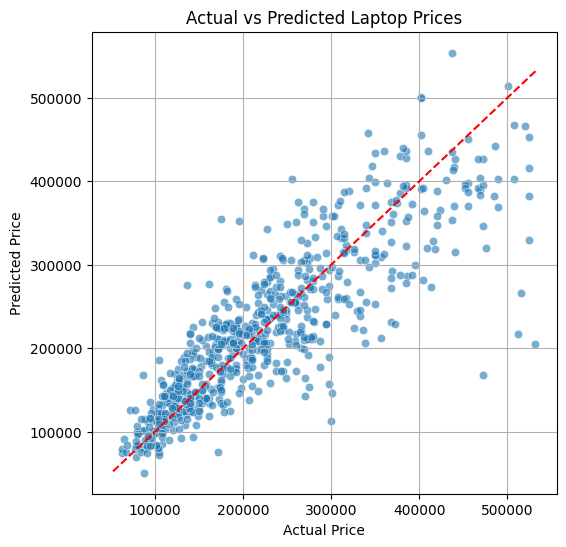

In [14]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.grid(True)
plt.show()

In [15]:
# Save trained pipeline and feature names
import joblib

# Save pipeline (model + preprocessing) to `pipeline.pkl`
joblib.dump(poly_ridge_model, 'pipeline.pkl')

# Save feature names if available (useful for downstream inference)
try:
    feature_names = X_train.columns.tolist()
    joblib.dump(feature_names, 'feature_names.pkl')
except Exception as e:
    print('Could not save feature names:', e)